https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

Dataset German Credit Data with Risk trên Kaggle (do tác giả Kabure xử lý lại từ nguồn gốc của UCI Machine Learning) là một trong những tập dữ liệu kinh điển và phổ biến nhất trong bài toán Credit Scoring (Chấm điểm tín dụng) và Quản trị rủi ro tài chính (Credit Risk Management)

1. Tổng quan về DatasetQuy mô: Thường bao gồm 1,000 dòng (ứng với 1,000 khách hàng xin vay vốn tại ngân hàng) và khoảng 20-21 thuộc tính (columns).   Bối cảnh: Bản gốc từ giáo sư Prof. Hofmann có các mã hóa ký hiệu tiếng Đức khá phức tạp (như A11, A12...). Phiên bản trên Kaggle đã được chuyển đổi tên cột sang tiếng Anh rõ nghĩa, rất sạch và thân thiện để đưa vào các thuật toán Machine Learning.Bài toán chính: Đây là bài toán Classification (Phân loại nhị phân). Dựa vào thông tin tài chính và nhân khẩu học của khách hàng, mô hình cần dự đoán xem khách hàng đó thuộc diện Rủi ro tốt (Good Credit) hay Rủi ro xấu (Bad Credit).

2. Giải thích các Cột (Features) quan trọng trong DatasetCác biến trong tập dữ liệu phản ánh lịch sử tài chính, nhân khẩu học và mục đích vay vốn:Checking Account Status (Status): Tình trạng tài khoản thanh toán hiện tại của khách hàng tại ngân hàng (ví dụ: số dư âm, dưới một mức tiền nào đó, hay có tài khoản ổn định).   Duration: Thời hạn vay vốn (tính bằng tháng, ví dụ: 12 tháng, 24 tháng...).   Credit History: Lịch sử tín dụng quá khứ (đã từng trả nợ đúng hạn, từng vỡ nợ, hay có các khoản vay khác đang chạy tốt không).   Purpose: Mục đích sử dụng khoản vay (mua ô tô mới, mua đồ điện tử, nội thất, đi học, kinh doanh...).   Credit Amount (Amount): Số tiền xin vay (đơn vị tiền tệ, ví dụ: USD hoặc Deutsche Mark). Đây là biến số lượng quan trọng.   Savings Account/Bonds (Savings): Số dư tài khoản tiết kiệm hoặc các khoản đầu tư/trái phiếu tích lũy của khách hàng.   Employment Duration: Thời gian làm việc ổn định tại công ty hiện tại (tính bằng năm).   Installment Rate: Tỷ lệ trả góp hàng tháng so với tổng thu nhập khả dụng (tính bằng phần trăm).   Personal Status & Sex: Giới tính kết hợp với tình trạng hôn nhân (ví dụ: nam độc thân, nữ đã kết hôn...).   Other Debtors / Guarantors: Khách hàng có người bảo lãnh hoặc người đồng trả nợ nào khác không.   Present Residence: Thời gian đã sinh sống tại nơi ở hiện tại (tính bằng năm).   Property: Tài sản sở hữu có giá trị lớn nhất (bất động sản, xe hơi, bảo hiểm nhân thọ hay không có gì).   Age: Tuổi của khách hàng (tính bằng năm).   Other Installment Plans: Khách hàng có đang tham gia các khoản trả góp hoặc mua trả góp ở nơi khác ngoài ngân hàng này không.   Housing: Hình thức nhà ở hiện tại (đang thuê nhà, ở nhà thuê mua, hay đã sở hữu nhà riêng).   Number Existing Credits: Tổng số khoản vay tín dụng hiện tại mà khách hàng đang có tại ngân hàng này.Job: Loại công việc / phân loại nghề nghiệp (lao động phổ thông, nhân viên kỹ thuật, quản lý/tự doanh...).   People Liable (Dependents): Số lượng người phụ thuộc (người thân/con cái) sống dựa vào tài chính của khách hàng.Telephone: Khách hàng có đăng ký số điện thoại đứng tên riêng hay không.   Foreign Worker: Khách hàng có phải là lao động nước ngoài hay không. 

3. Biến Mục tiêu (Target Variable)Credit Risk (hoặc Risk / Response):Thường được gán nhãn là 1 (Good Risk): Khách hàng uy tín, trả nợ đầy đủ, rủi ro thấp.   Thường được gán nhãn là 0 hoặc 2 (Bad Risk): Khách hàng có nguy cơ vỡ nợ, trả chậm, rủi ro cao. (Lưu ý: Tùy phiên bản script chuyển đổi của Kaggle, nhãn có thể là 1/0 hoặc 1/2, bạn cần kiểm tra lại giá trị unique của cột target này khi load dataframe).

4. Ý nghĩa thực tế và Thách thức khi phân tích dataset này
Ý nghĩa Kinh doanh: Giúp các ngân hàng và tổ chức tài chính tự động hóa quy trình xét duyệt khoản vay. Nếu mô hình dự đoán sai một khách hàng rủi ro thành tốt (False Negative), ngân hàng sẽ mất tiền. Do đó, bài toán này rất coi trọng các chỉ số như Precision, Recall, ROC-AUC thay vì chỉ nhìn vào độ chính xác tổng thể (Accuracy).

Mối quan hệ dữ liệu thường thấy:

Những khoản vay có Amount lớn và Duration dài thường đi kèm với rủi ro cao hơn.

Khách hàng có Checking Account số dư tốt hoặc có Savings cao thường tỷ lệ trả nợ (Good Risk) cao hơn hẳn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("german_credit_data.csv")

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [ ]:
df.shape

(1000, 11)

In [ ]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [ ]:
df["Job"].unique()

array([2, 1, 3, 0])

dùng để liệt kê tất cả các giá trị duy nhất (không bị trùng lặp) có trong cột Job của bảng dữ liệu df.

In [ ]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [ ]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
df.drop(columns = "Unnamed: 0", inplace=True)

In [ ]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

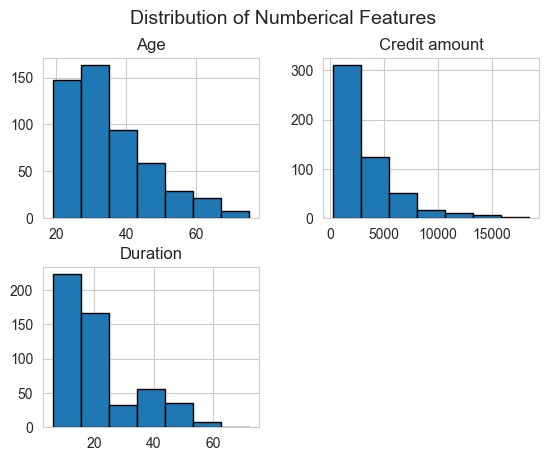

In [ ]:
df[["Age", "Credit amount", "Duration"]].hist(bins=7, edgecolor="black")
plt.suptitle("Distribution of Numberical Features", fontsize=14)
plt.show()

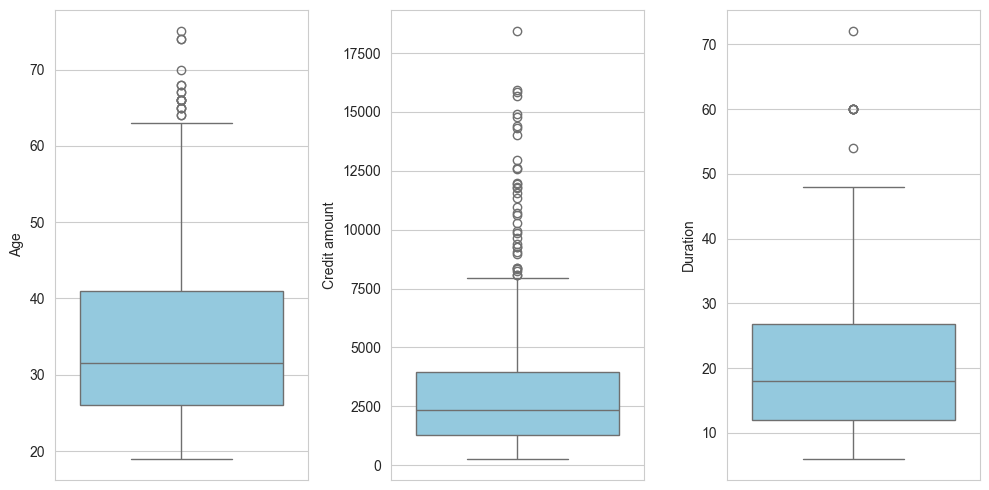

In [ ]:
plt.figure(figsize=(10,5))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3, i+1)
    sns.boxplot(y=df[col], color="skyblue")

plt.tight_layout()
plt.show()

In [ ]:
df.query("Duration >= 60")


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


dùng để lọc ra các dòng (hàng) trong bảng dữ liệu df mà có giá trị ở cột Duration (thời hạn vay) lớn hơn hoặc bằng 60 tháng (tức là các khoản vay dài hạn từ 5 năm trở lên).

In [ ]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

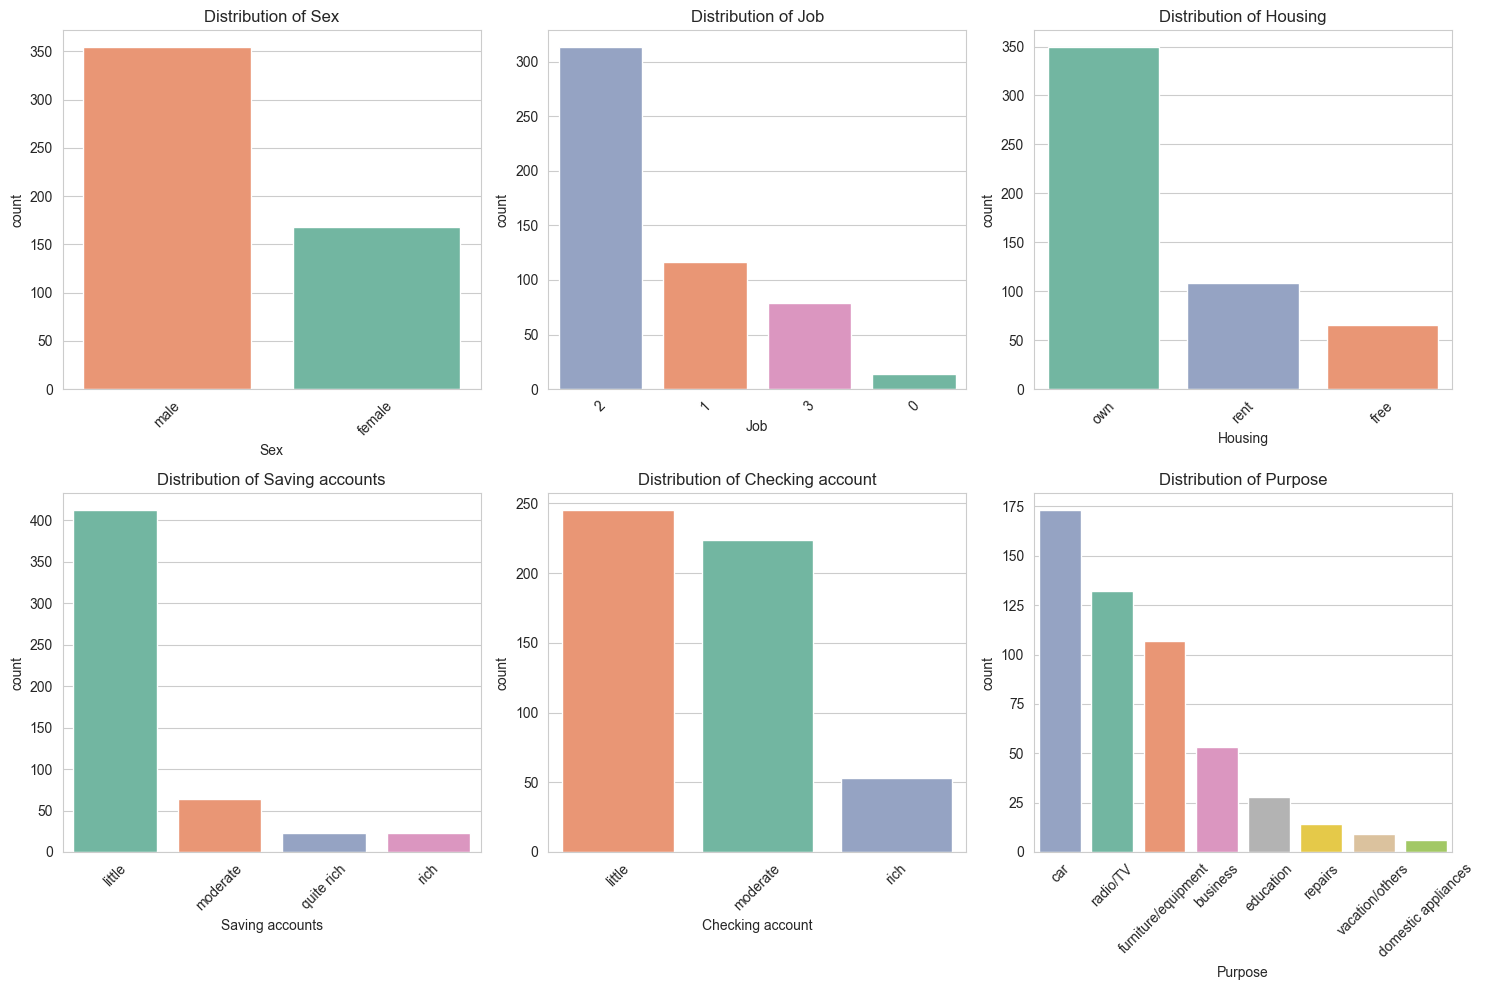

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    # Dùng lưới 2 hàng, 3 cột (2x3 = 6 ô vừa khít cho 6 biến)
    plt.subplot(2, 3, i + 1)
    
    # Thêm hue=col và legend=False để tương thích với các phiên bản Seaborn mới nhất
    sns.countplot(
        data=df, 
        x=col, 
        hue=col, 
        palette="Set2", 
        legend=False, 
        order=df[col].value_counts().index
    )
    
    # Thêm chữ f để f-string hoạt động chính xác
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

dùng để tính toán ma trận hệ số tương quan (correlation matrix) giữa các cột dạng số được chọn trong bảng dữ liệu.

.corr():

Là phương thức của Pandas dùng để tính toán mức độ tương quan tuyến tính giữa các cột với nhau (mặc định sử dụng phương pháp Pearson).

Giá trị tương quan trả về nằm trong khoảng từ -1 đến 1:

Gần bằng 1: Tương quan thuận mạnh (khi biến này tăng thì biến kia cũng tăng).

Gần bằng -1: Tương quan nghịch mạnh (khi biến này tăng thì biến kia giảm).

Gần bằng 0: Không có mối quan hệ tuyến tính giữa hai biến.

In [ ]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


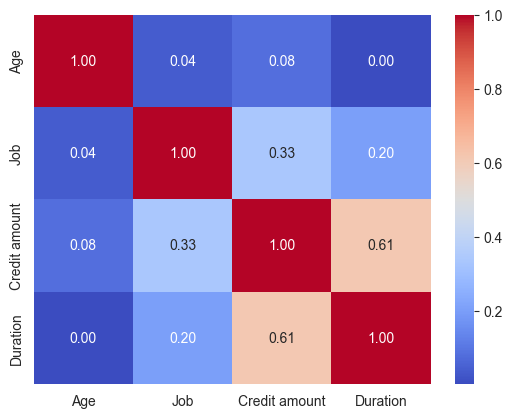

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

để tính toán mức số tiền vay trung bình (mean) của từng nhóm nghề nghiệp/cấp bậc công việc khác nhau trong bảng dữ liệu.

In [ ]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [ ]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


dùng để tạo một bảng tổng hợp chéo (Pivot Table), giúp bạn xem xét mức số tiền vay trung bình (hoặc tổng) theo hai chiều thông tin cùng một lúc: hình thức nhà ở và mục đích vay.

Cụ thể chi tiết từng tham số trong hàm:

df: Bảng dữ liệu nguồn (DataFrame) chứa thông tin tín dụng.

values="Credit amount": Đây là giá trị số liệu (metrics) mà bạn muốn tính toán và điền vào các ô bên trong bảng (ở đây là cột Credit amount - số tiền vay). Lưu ý: Mặc định của pivot_table nếu không truyền hàm tổng hợp (aggfunc) thì nó sẽ lấy giá trị trung bình (mean).

index="Housing": Các giá trị trong cột Housing (ví dụ: own, rent, free) sẽ trở thành các hàng (rows) của bảng mới.

columns="Purpose": Các giá trị duy nhất trong cột Purpose (ví dụ: car, business, radio/tv, furniture...) sẽ được rải ra thành các cột (columns) ngang của bảng mới.

Text(0.5, 1.0, 'Credit amount vs Age colored by Sex and sized by Duration')

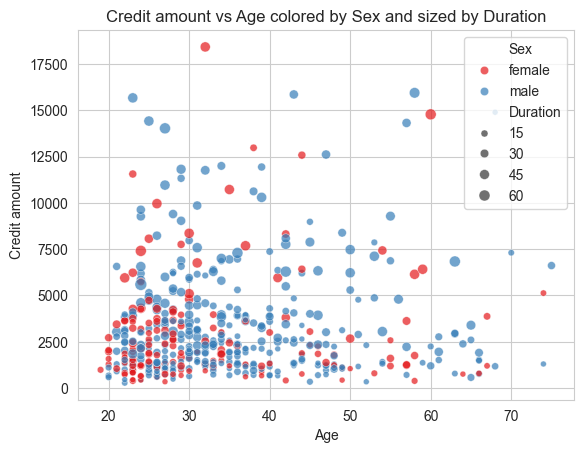

In [ ]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")

C:\Users\mbw2025\AppData\Local\Temp\ipykernel_2368\1038748578.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


Text(0.5, 1.0, 'Credit Amount Distribution by Saving Account')

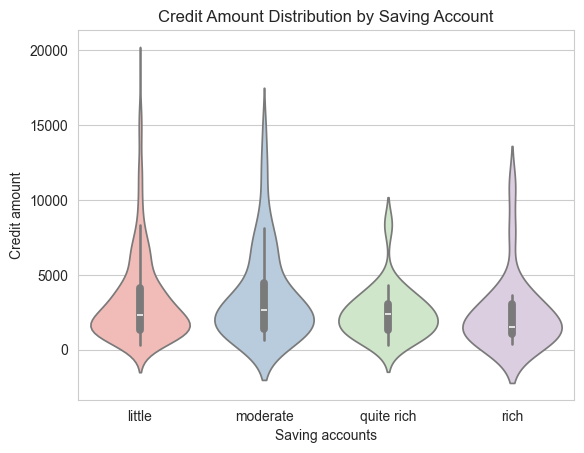

In [ ]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Account")

In [ ]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

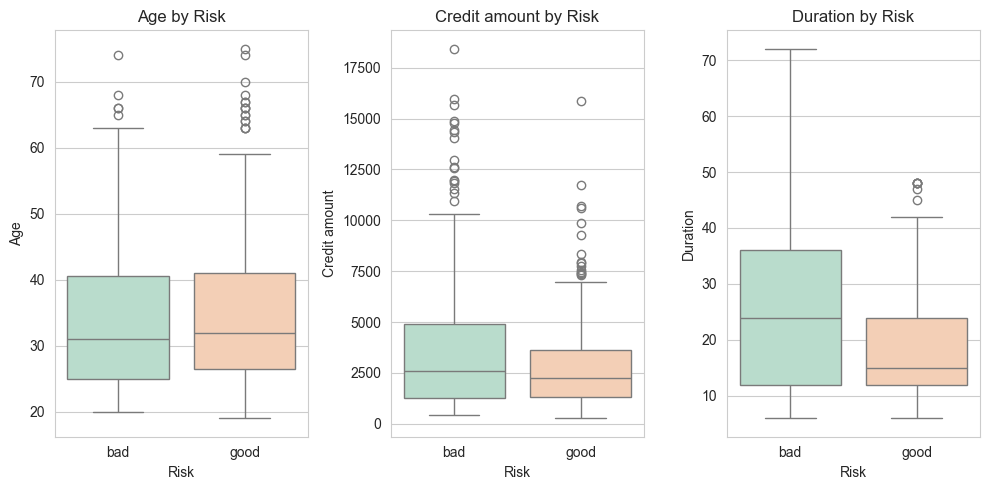

In [ ]:
plt.figure(figsize=(10, 5))

for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    
    # Thêm hue="Risk" và legend=False để fix cảnh báo Seaborn
    sns.boxplot(
        data=df, 
        x="Risk", 
        y=col, 
        hue="Risk", 
        palette="Pastel2", 
        legend=False
    )
    
    # Sửa thành f-string để hiển thị đúng tên biến
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


để tính giá trị trung bình (mean) của các cột số liệu (Age, Credit amount, Duration) sau khi đã phân loại theo từng nhóm rủi ro tín dụng (Risk).

Cụ thể chi tiết từng phần trong câu lệnh:

df.groupby("Risk"):

Gom nhóm toàn bộ dữ liệu trong bảng df dựa theo cột Risk (trong bộ dữ liệu German Credit, cột này chứa nhãn rủi ro như "good" hoặc "bad").

[["Age", "Credit amount", "Duration"]]:

Lọc ra 3 cột số lượng cụ thể mà bạn muốn phân tích:

Age: Tuổi của khách hàng.

Credit amount: Số tiền vay.

Duration: Thời hạn vay (tháng).

.mean():

Tính toán giá trị trung bình cộng cho từng cột trên ở mỗi nhóm rủi ro.

In [ ]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

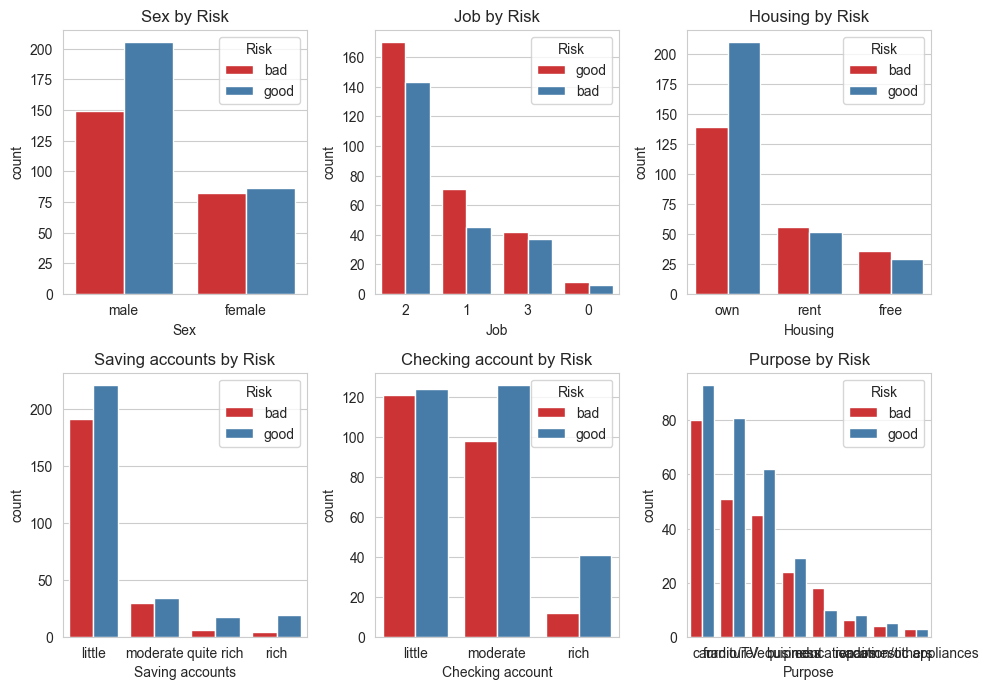

In [ ]:
plt.figure(figsize=(10, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(
        data=df, 
        x=col, 
        hue="Risk", 
        palette="Set1", 
        order=df[col].value_counts().index
    )
    
    # Sửa thành f-string để hiển thị đúng tên biến
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [ ]:
features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']

In [ ]:
target = "Risk"

In [ ]:
df_model = df[features + [target]].copy()

In [ ]:
df_model.head()

,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,female,2,own,little,moderate,5951,48,bad
1,male,2,free,little,little,7882,42,good
2,male,2,free,little,little,4870,24,bad
3,male,3,rent,little,moderate,6948,36,good
4,male,3,own,little,moderate,5234,30,bad


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

In [ ]:
le_dict = {}

In [ ]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

để mã hóa (encode) các biến dạng phân loại (categorical columns) thành dạng số nguyên bằng thuật toán LabelEncoder, đồng thời lưu lại (dump) các bộ mã hóa (encoder) ra file để sau này có thể dùng lại khi dự báo dữ liệu mới.

le = LabelEncoder():

Khởi tạo một đối tượng mã hóa LabelEncoder của thư viện scikit-learn. Công cụ này có nhiệm vụ chuyển đổi các giá trị dạng chữ (ví dụ: male, female hoặc own, rent, free) thành các con số nguyên (ví dụ: 0, 1, 2).

df_model[col] = le.fit_transform(df_model[col]):

fit_transform(...): Học các danh mục có trong cột đó và tiến hành chuyển đổi trực tiếp các giá trị chữ trong bảng df_model thành các con số tương ứng. Việc này bắt buộc phải làm vì các thuật toán Machine Learning (như Extra Trees, Random Forest, XGBoost) chỉ hiểu được dữ liệu dạng số.

le_dict[col] = le:

Lưu lại đối tượng le vừa huấn luyện vào một từ điển (dictionary) có tên là le_dict với khóa (key) là tên cột. Việc này giúp bạn quản lý tất cả encoder gọn gàng trong bộ nhớ.

joblib.dump(le, f"{col}_encoder.pkl"):

Sử dụng thư viện joblib để lưu tệp đối tượng encoder xuống ổ đĩa cứng với tên file động (ví dụ: Sex_encoder.pkl, Housing_encoder.pkl,... chuẩn bị cho ứng dụng Streamlit ở trên).

Ý nghĩa thực tế: Khi người dùng nhập liệu trên giao diện web (chọn giới tính là "male"), bạn cần dùng đúng cái encoder của cột Sex đã được lưu ở bước này để chuyển "male" thành con số chính xác mà mô hình đã được học lúc huấn luyện.

In [ ]:
le_target = LabelEncoder()

In [ ]:
target

'Risk'

In [ ]:
df_model[target] = le_target.fit_transform(df_model[target])

dùng để mã hóa (chuyển đổi) biến mục tiêu (target) từ dạng chữ (text) sang dạng số nguyên (integer) để phục vụ cho việc huấn luyện mô hình Machine Learning.

Cụ thể chi tiết từng phần trong câu lệnh:

df_model[target]:

Truy cập vào cột mục tiêu (cột nhãn / nhãn nhãn lớp - label) trong bảng dữ liệu mô hình df_model. Biến target ở đây thường là cột chứa kết quả bạn muốn dự đoán (ví dụ: cột Risk với các giá trị chữ như "good" hoặc "bad").

le_target:

Là một đối tượng LabelEncoder (đã được khởi tạo từ trước bằng thư viện scikit-learn), chuyên dùng để mã hóa nhãn mục tiêu.

.fit_transform(...):

Phương thức này thực hiện hai việc cùng một lúc:

fit: Quét qua toàn bộ cột target để học tất cả các giá trị duy nhất tồn tại (ví dụ: học được 2 nhãn "bad" và "good").

transform: Chuyển đổi toàn bộ các giá trị chữ đó thành các con số tương ứng (ví dụ: "bad" thành 0 và "good" thành 1, hoặc ngược lại tùy thuộc vào thứ tự bảng chữ cái).

df_model[target] = ...:

Ghi đè lại cột mục tiêu cũ (dạng chữ) trong bảng df_model bằng cột mới chứa các con số đã được mã hóa.

In [ ]:
df_model[target]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [ ]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [ ]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [ ]:
df_model.head()

,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,0,2,1,0,1,5951,48,0
1,1,2,0,0,0,7882,42,1
2,1,2,0,0,0,4870,24,0
3,1,3,2,0,1,6948,36,1
4,1,3,1,0,1,5234,30,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_model.drop(target, axis=1)

In [ ]:
y = df_model[target]

In [ ]:
X

,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,0,2,1,0,1,5951,48
1,1,2,0,0,0,7882,42
2,1,2,0,0,0,4870,24
3,1,3,2,0,1,6948,36
4,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...
517,1,1,1,0,1,1743,24
518,1,3,1,0,0,3959,36
519,1,3,1,0,0,3857,30
520,1,2,0,0,0,1845,45


In [ ]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [ ]:
X_train.shape

(417, 7)

In [ ]:
X_test.shape

(105, 7)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier:

Nhập thuật toán Cây quyết định (Decision Tree). Đây là một mô hình học máy cơ bản hoạt động bằng cách chia dữ liệu thành các nhánh dựa trên các điều kiện của đặc trưng (features).

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier:

Nhập hai thuật toán học kết hợp (Ensemble Learning) dựa trên cây quyết định:

RandomForestClassifier (Rừng ngẫu nhiên): Xây dựng nhiều cây quyết định độc lập trên các tập dữ liệu con lấy mẫu ngẫu nhiên và gộp kết quả lại để đưa ra dự đoán chính xác hơn, chống overfitting tốt hơn cây đơn lẻ.

ExtraTreesClassifier (Extremely Randomized Trees): Một biến thể của Random Forest, trong đó các điểm chia (split points) tại mỗi nút của cây được chọn hoàn toàn ngẫu nhiên thay vì tìm kiếm điểm chia tối ưu nhất, giúp tốc độ huấn luyện nhanh hơn và đôi khi giảm thiểu hiện tượng quá khớp (overfitting) tốt hơn.

from xgboost import XGBClassifier:

Nhập thuật toán XGBoost (Extreme Gradient Boosting) từ thư viện xgboost. Đây là một trong những thuật toán học máy mạnh mẽ và phổ biến nhất hiện nay, hoạt động theo cơ chế huấn luyện tuần tự các cây quyết định (boosting) để cây sau sửa lỗi cho cây trước.

from sklearn.metrics import accuracy_score:

Nhập hàm đo lường độ chính xác (Accuracy). Dùng để tính toán tỷ lệ phần trăm các dự đoán đúng của mô hình so với nhãn thực tế trên tập dữ liệu kiểm tra (test set).

from sklearn.model_selection import GridSearchCV:

Nhập công cụ Grid Search Cross-Validation. Đây là một kỹ thuật giúp bạn tự động thử nghiệm tất cả các tổ hợp thông số (hyperparameters) mà bạn định nghĩa trước để tìm ra bộ thông số tối ưu nhất cho mô hình thông qua phương pháp kiểm định chéo.

In [ ]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [ ]:
dt = DecisionTreeClassifier(random_state = 1, class_weight="balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [ ]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [ ]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.638095238095238


In [ ]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [ ]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [ ]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [ ]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6666666666666666


In [ ]:
print("Best params", params_rf)

Best params {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
et_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [ ]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [ ]:
print("Extra trees accuracy", acc_et)

Extra trees accuracy 0.6190476190476191


In [ ]:
print("Best params", params_et)

Best params {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
xgb = XGBClassifier(
    random_state=1, 
    scale_pos_weight=(y_train == 0).sum() / (y_train==1).sum(), 
    use_label_encoder=False, 
    eval_metric="logloss"
    )

In [ ]:
xgb_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7,1],
    "colsample_bytree": [0.7,1]
}

In [ ]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [ ]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.6761904761904762


In [ ]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [ ]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1])

In [ ]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']

In [110]:
df["Saving accounts"].unique()

array(['little', 'moderate', 'quite rich', 'rich'], dtype=object)

In [113]:
df["Checking account"].unique()

array(['moderate', 'little', 'rich'], dtype=object)